# Hospital Readmission Risk Prediction

Dataset from Kaggle: https://www.kaggle.com/datasets/miadul/hospital-readmission-risk-dataset/data 

The goal of this project is to predict the risk of re-hospitalization of a patient. Classification problem with 3 classes.

Content:
1. [EDA](#eda-section)
    1. General dataset information
    2. Target variable analysis and class balance
    3. Invalid and missing values check
    4. Numerical attribute analysis and outlier detection
    5. Categorical attributes analysis
    6. Correlation matrix
2. [Preprocessing](#preprocessing-section)
    1. Data cleaning
    2. Feature Selection
    3. Encoding
    4. Train test split
    5. Data standardization
    6. PCA visualization

3. [Machine learning algorithms and optimization](#algorithm-section)
    1. Hyperparameter Tuning on Original Features
        1. Logistic Regression
        2. KNN
        3. Decision Tree
        4. Random Forest
    2. Hyperparameter Tuning on PCA Features
        1. Logistic Regression
        2. KNN
    3. Hyperparameter Tuning on LDA Features
        1. Logistic Regression
        2. KNN

4. [Model Evaluation and Comparison](#evaluation-section)
    1. Baseline model (Logistic Regression)
    2. Final Evaluation on Test Set
    3. Model Comparison Table
    4. Confusion Matrix Analysis
    5. Interpretation of Results
    6. Final Conclusion

In [559]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import warnings

warnings.filterwarnings('ignore')

<a id="eda-section"></a>
# EDA

In [560]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
df = pd.read_csv("hospital_readmission_risk_10000.csv")
print(f"Shape of the dataset: {df.shape}")
display(df.head())

Shape of the dataset: (9999, 23)


,patient_id,age,gender,weight_kg,height_cm,bmi,num_previous_admissions,chronic_conditions,medications_count,last_hemoglobin,...,length_of_stay,procedures_count,smoking_status,alcohol_use,physical_activity,insurance_type,followup_compliance,social_support,mental_health_issue,readmission_risk
0,d8fd1a56-a5d8-499b-917c-f9ac8d369f9b,18,Male,57,157,23.10,8,Heart Disease,8,16.20,...,7,0,Current,Moderate,Medium,Private,Poor,Weak,Yes,Medium
1,2e9b4349-69e5-494f-b806-947ec5b5bb7c,23,Female,117,150,52.00,6,Diabetes,6,13.10,...,21,2,Never,High,Medium,Private,Good,Weak,Yes,High
2,6f279c22-3b20-4328-9dac-466de7c47a51,80,Female,61,141,30.70,5,Heart Disease,8,15.40,...,2,0,Never,Moderate,Low,Public,Good,Weak,No,Low
3,1af43d48-79a9-4408-a1f1-13c58d7221fd,15,Female,47,164,17.50,0,Hypertension,1,14.20,...,8,3,Former,NaN,High,Private,Good,Weak,No,High
4,e7903dbe-839e-4ea6-a6d0-83438a981a9b,14,Male,67,179,20.90,6,Heart Disease,0,14.70,...,3,0,Former,High,High,Uninsured,Poor,Weak,No,Medium


In [561]:
print("Types of data:")
print(df.dtypes)


Types of data:
patient_id                     str
age                          int64
gender                         str
weight_kg                    int64
height_cm                    int64
bmi                        float64
num_previous_admissions      int64
chronic_conditions             str
medications_count            int64
last_hemoglobin            float64
last_glucose               float64
last_creatinine            float64
admission_type                 str
length_of_stay               int64
procedures_count             int64
smoking_status                 str
alcohol_use                    str
physical_activity              str
insurance_type                 str
followup_compliance            str
social_support                 str
mental_health_issue            str
readmission_risk               str
dtype: object


**Analyzing the target variable**

Text(0, 0.5, 'Count')

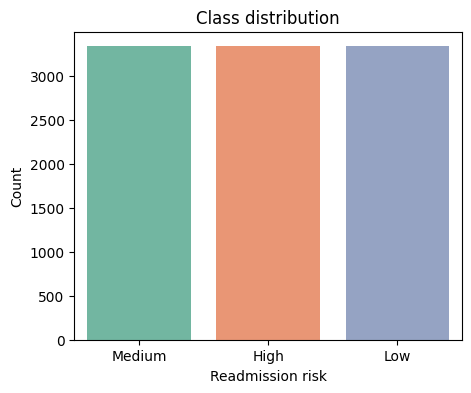

In [562]:
plt.figure(figsize=(5,4))
sns.countplot(x=df['readmission_risk'], palette='Set2')
plt.title("Class distribution")
plt.xlabel('Readmission risk')
plt.ylabel('Count')

**Check missing or invalid values**

In [563]:
missing_values = df.isnull().sum()
print("Missing values analysis: ")
print(missing_values[missing_values > 0])

Missing values analysis: 
chronic_conditions    2032
alcohol_use           3243
dtype: int64


In [564]:
print(df['chronic_conditions'].unique())
print(df['alcohol_use'].unique())

<StringArray>
['Heart Disease', 'Diabetes', 'Hypertension', nan, 'COPD']
Length: 5, dtype: str
<StringArray>
['Moderate', 'High', nan]
Length: 3, dtype: str


This dataset actually has a category 'None' in columns 'alcohol_use' and 'chronic_conditions' that indicates that the patient doesn't drink alcohol or doesn't have any chronic conditions.

We will solve this in the [**Preprocessing**](#preprocessing-section) section

In [565]:
df.describe()

,age,weight_kg,height_cm,bmi,num_previous_admissions,medications_count,last_hemoglobin,last_glucose,last_creatinine,length_of_stay,procedures_count
count,9999.00,9999.00,9999.00,9999.00,9999.00,9999.00,9999.00,9999.00,9999.00,9999.00,9999.00
mean,44.46,79.25,169.38,28.55,4.50,4.43,13.99,135.49,1.24,15.05,2.01
std,25.99,23.17,17.35,10.45,2.87,2.87,2.30,37.49,0.44,8.36,1.41
min,0.00,40.00,140.00,10.10,0.00,0.00,10.00,70.00,0.50,1.00,0.00
25%,22.00,59.00,154.00,20.40,2.00,2.00,12.00,102.80,0.86,8.00,1.00
50%,45.00,79.00,169.00,27.40,5.00,4.00,14.00,135.50,1.24,15.00,2.00
75%,67.00,99.00,184.50,35.10,7.00,7.00,16.00,168.40,1.62,22.00,3.00
max,89.00,119.00,199.00,60.20,9.00,9.00,18.00,200.00,2.00,29.00,4.00


Min and max 'bmi' values are extreme, but also medically possible, so we will not exclude them.

Min 'age' is 0, which indicates the presence of newborns, we will also consider that a valid value.

Conclusion: no invalid values present in dataset

**Numerical attribute analysis**

In [566]:
numerical_cols = df.select_dtypes(include=np.number).columns.to_list()
print(f"Number od numerical columns: {len(numerical_cols)}") 
print(numerical_cols)

Number od numerical columns: 11
['age', 'weight_kg', 'height_cm', 'bmi', 'num_previous_admissions', 'medications_count', 'last_hemoglobin', 'last_glucose', 'last_creatinine', 'length_of_stay', 'procedures_count']


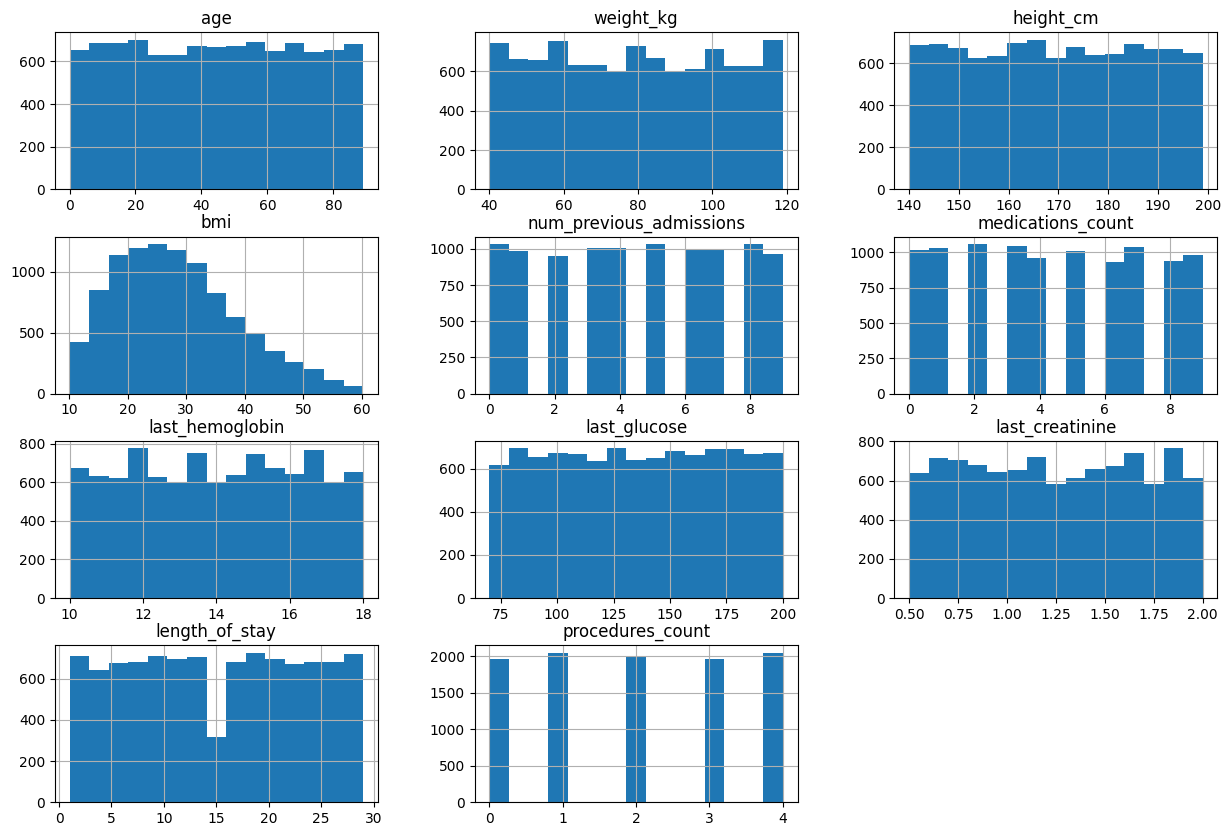

In [567]:
df[numerical_cols].hist(bins = 15, figsize=(15,10))
plt.show()

<Axes: >

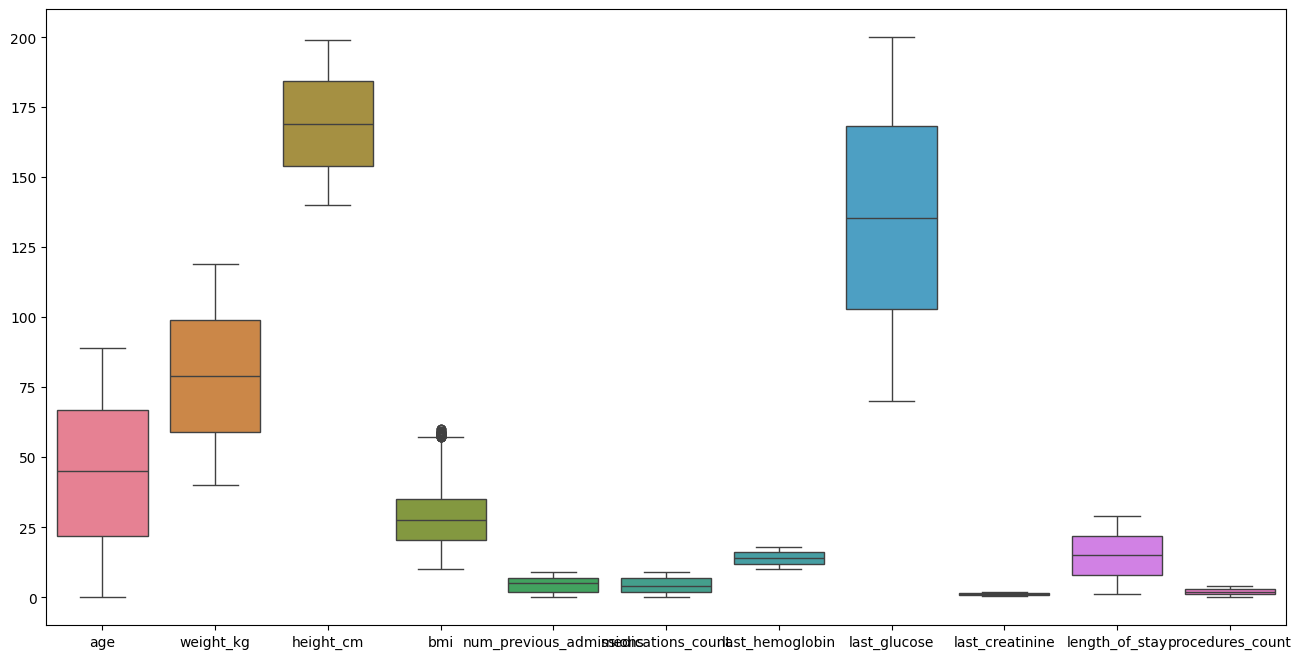

In [568]:
plt.figure(figsize=(16, 8))
sns.boxplot(data=df[numerical_cols])

<Axes: xlabel='bmi'>

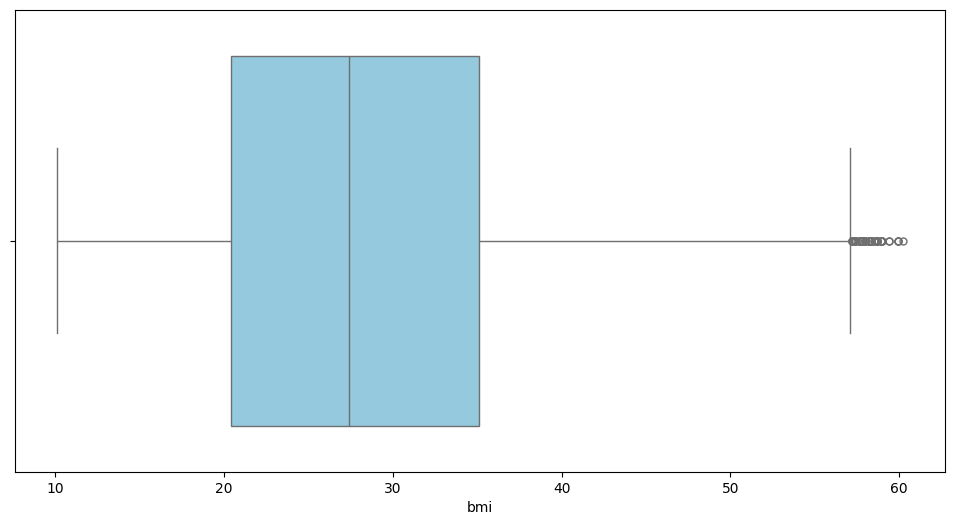

In [569]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['bmi'], color='skyblue', fliersize=5)

In [570]:
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['bmi'] < lower_bound) | (df['bmi'] > upper_bound)]

print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"Number of outliers: {len(outliers)}")
display(outliers.head())


Lower bound: -1.6500000000000057
Upper bound: 57.150000000000006
Number of outliers: 52


,patient_id,age,gender,weight_kg,height_cm,bmi,num_previous_admissions,chronic_conditions,medications_count,last_hemoglobin,...,length_of_stay,procedures_count,smoking_status,alcohol_use,physical_activity,insurance_type,followup_compliance,social_support,mental_health_issue,readmission_risk
19,8f1c9eee-fd89-47ef-a932-3d47cfe2afc7,72,Female,119,144,57.40,4,COPD,0,16.00,...,8,4,Former,Moderate,High,Public,Poor,Weak,Yes,Medium
688,afb828b9-db28-4bbc-9cc5-29fc5deb7271,13,Female,119,144,57.40,1,NaN,9,11.90,...,11,4,Current,High,High,Private,Good,Weak,Yes,High
1042,5389fb7d-f809-4318-9290-dfb717bd3673,72,Male,115,140,58.70,5,Diabetes,2,15.60,...,1,2,Current,High,Medium,Uninsured,Good,Weak,No,High
1136,b1bd61c5-bddf-4c08-b848-d57be482190b,82,Female,115,141,57.80,1,Diabetes,0,12.90,...,15,1,Former,High,Medium,Public,Good,Strong,Yes,Medium
1427,95fdd21f-25f9-457e-a352-90f5b4b351e9,21,Female,115,141,57.80,4,Hypertension,9,10.80,...,17,2,Current,Moderate,Medium,Uninsured,Poor,Weak,No,High


<Axes: xlabel='readmission_risk', ylabel='count'>

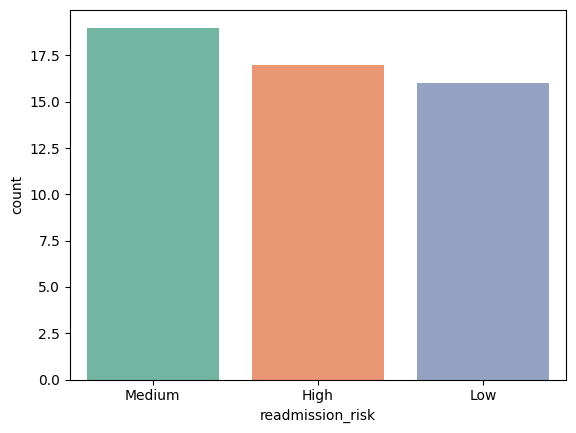

In [571]:
sns.countplot(data=outliers, x='readmission_risk', palette='Set2')

Analysis of extreme values ​​(outliers) in the BMI column showed that patients with an extremely high bmi do not necessarily belong to the high-risk group. The distribution of classes within outliers follows the general distribution of the entire data set. This suggests that BMI, although important, is not an isolated factor independently dictating the risk of rehospitalization in this dataset.

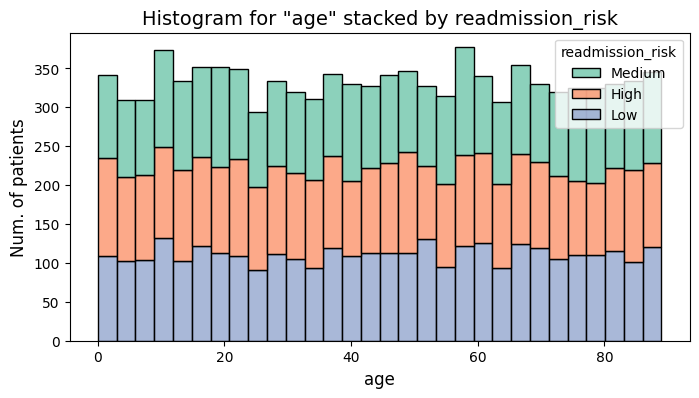

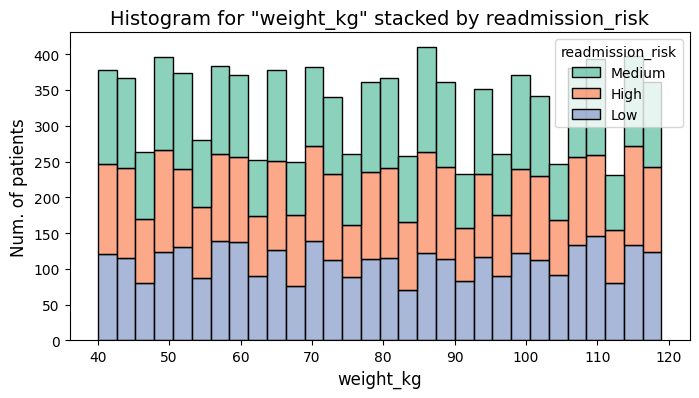

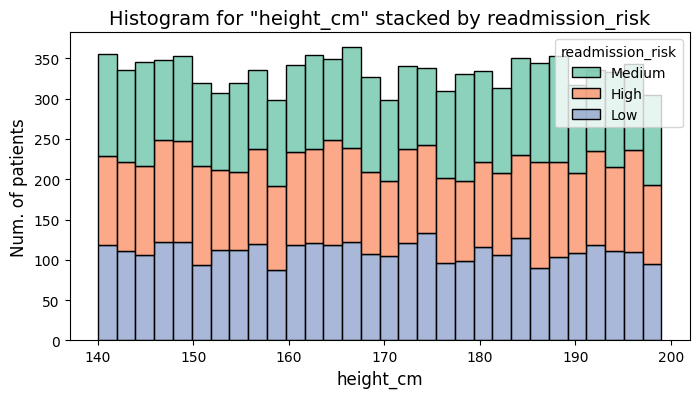

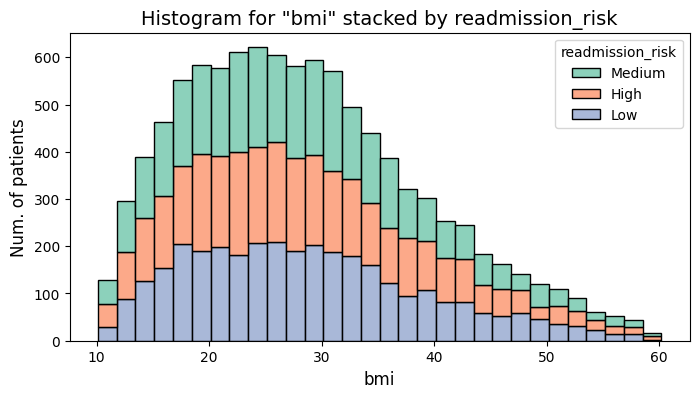

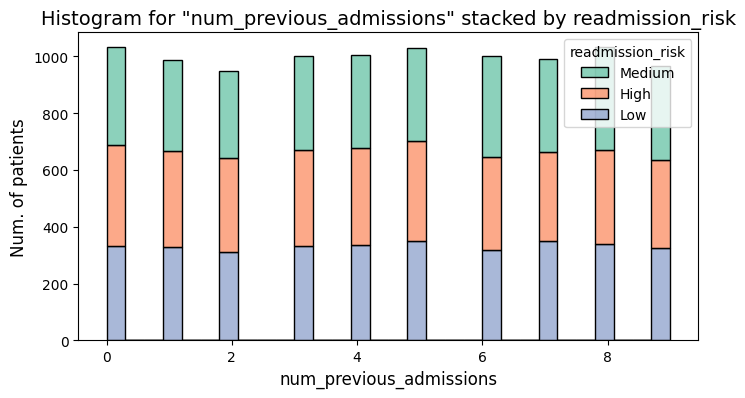

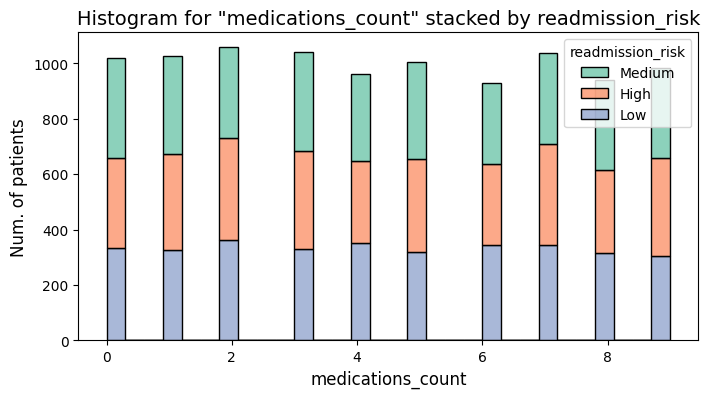

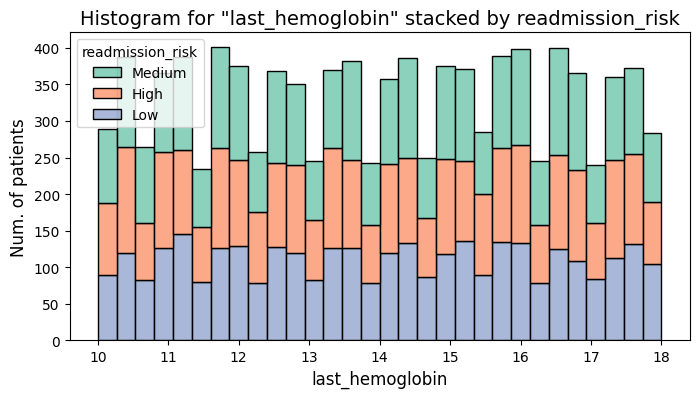

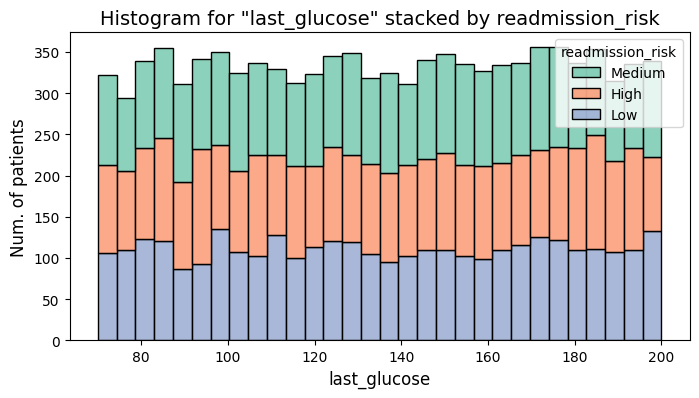

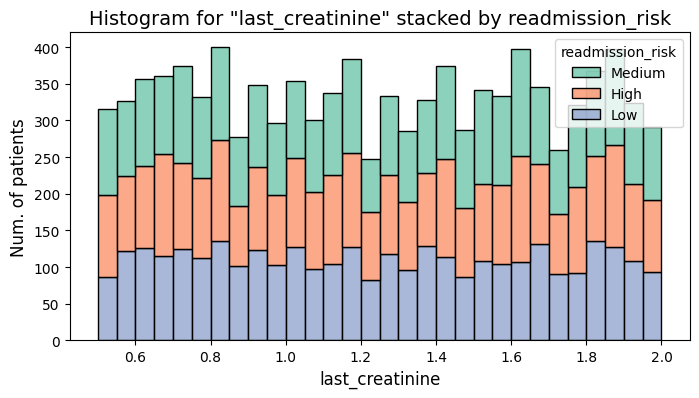

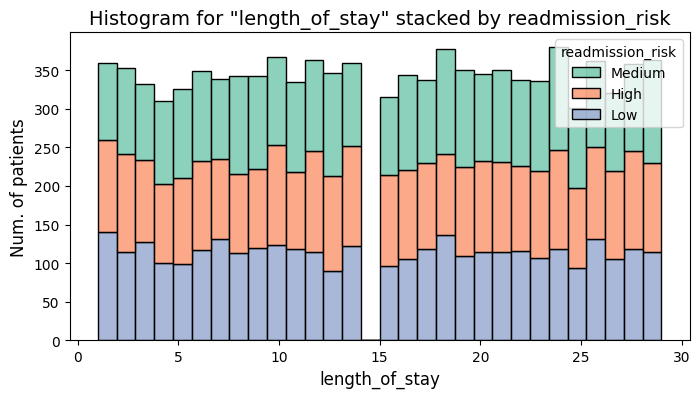

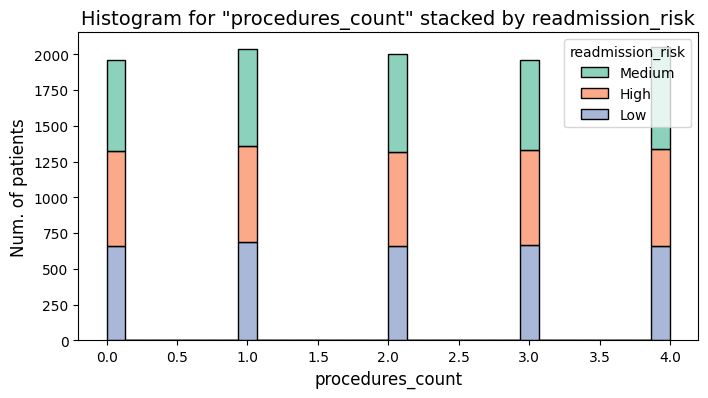

In [572]:
numerical_features = df.select_dtypes(include=[np.number]).drop(columns=['readmission_risk'], errors='ignore')
target_feature = 'readmission_risk'

for feature in numerical_features.columns:
    plt.figure(figsize=(8, 4))

    sns.histplot(data=df, x=feature, hue=target_feature, multiple='stack', palette='Set2', bins=30)
    
    plt.title(f'Histogram for "{feature}" stacked by {target_feature}', fontsize=14)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Num. of patients', fontsize=12)
    plt.show()

<a id="correlation-section"></a>
**Correlation matrix**

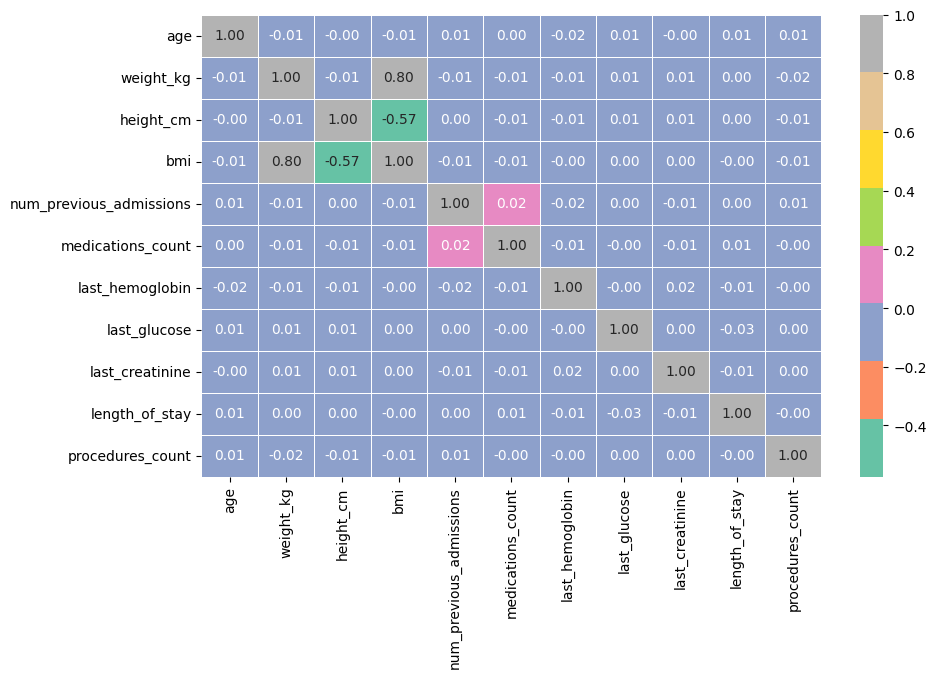

In [573]:
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Set2",   
    fmt=".2f",
    linewidths=.5
)
plt.show()

Conclusion: BMI is derived from weight and height, so we will only keep bmi to avoid redundancy.

<a id="preprocessing-section"></a>
# Preprocessing

**Data cleaning**

Pandas recognized the 'None' category  as NaN, so we will fill those 'missing' values with the string 'None'.

In [574]:
df['chronic_conditions'] = df['chronic_conditions'].fillna('None')
df['alcohol_use'] = df['alcohol_use'].fillna('None')

print(df['chronic_conditions'].value_counts())
print()
print(df['alcohol_use'].value_counts())

chronic_conditions
Diabetes         2034
None             2032
Hypertension     2021
COPD             1994
Heart Disease    1918
Name: count, dtype: int64

alcohol_use
High        3398
Moderate    3358
None        3243
Name: count, dtype: int64


This way, we brought back 'None' as a valid category

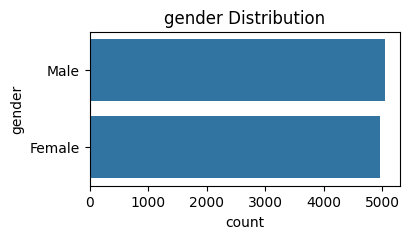

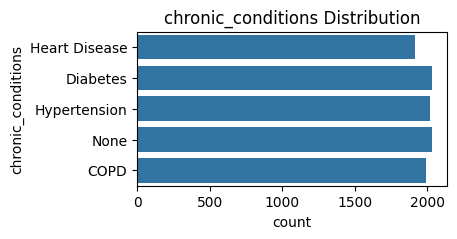

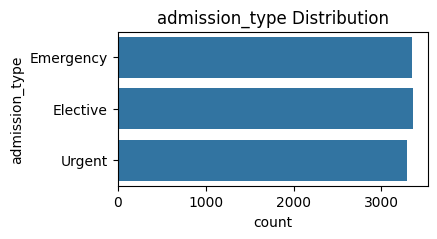

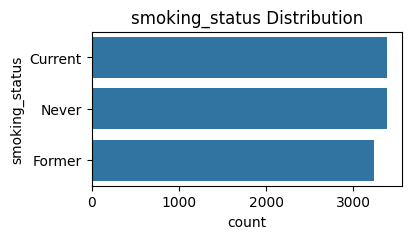

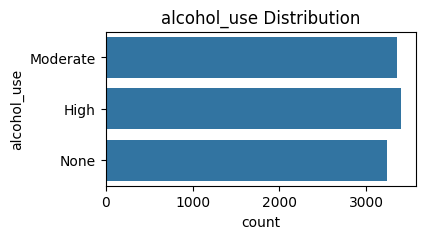

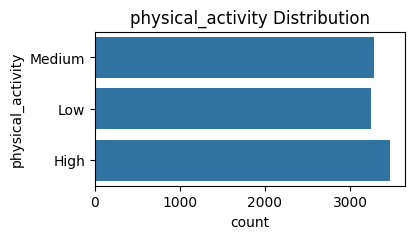

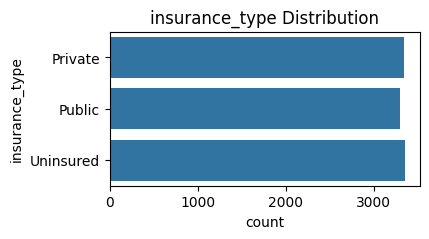

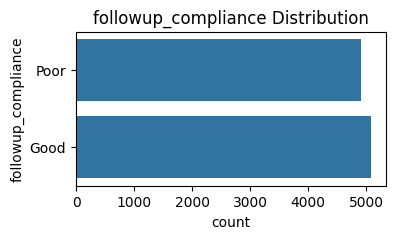

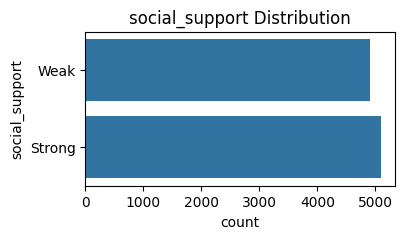

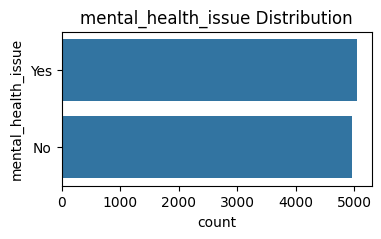

In [575]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('patient_id')
categorical_cols.remove('readmission_risk')

for col in categorical_cols:
    plt.figure(figsize=(4,2))
    sns.countplot(y=col, data=df)
    plt.title(f'{col} Distribution')
    plt.show()

**Feature Selection**

Correlation matrix in [**EDA**](#correlation-section) gave us an indication that height and weight are not needed, so we will remove those columns.

As well as column 'patient_id', which is irrelevant in this prediction.

In [576]:
df.drop(['patient_id','weight_kg', 'height_cm'], axis = 1, inplace = True)

**Encoding**

In [577]:
ordinal_mappings = {
    'physical_activity': {'Low': 0, 'Medium': 1, 'High': 2},
    'alcohol_use': {'None': 0, 'Moderate': 1, 'High': 2},
    'social_support': {'Weak': 0, 'Strong': 1},
    'followup_compliance': {'Poor': 0, 'Good': 1},
    'mental_health_issue': {'No': 0, 'Yes': 1}
}

for col, mapping in ordinal_mappings.items():
    df[col] = df[col].map(mapping)


df = pd.get_dummies(df, columns=['gender', 'smoking_status', 'chronic_conditions', 
                                       'admission_type', 'insurance_type'], drop_first=True)

le = LabelEncoder()
df['readmission_risk'] = le.fit_transform(df['readmission_risk'])

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)   # all bool values will be 1/0

mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)


{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [578]:
display(df.head())

,age,bmi,num_previous_admissions,medications_count,last_hemoglobin,last_glucose,last_creatinine,length_of_stay,procedures_count,alcohol_use,...,smoking_status_Former,smoking_status_Never,chronic_conditions_Diabetes,chronic_conditions_Heart Disease,chronic_conditions_Hypertension,chronic_conditions_None,admission_type_Emergency,admission_type_Urgent,insurance_type_Public,insurance_type_Uninsured
0,18,23.10,8,8,16.20,135.10,0.96,7,0,1,...,0,0,0,1,0,0,1,0,0,0
1,23,52.00,6,6,13.10,137.20,1.11,21,2,2,...,0,1,1,0,0,0,0,0,0,0
2,80,30.70,5,8,15.40,82.10,0.71,2,0,1,...,0,1,0,1,0,0,0,1,1,0
3,15,17.50,0,1,14.20,183.50,0.57,8,3,0,...,1,0,0,0,1,0,0,0,0,0
4,14,20.90,6,0,14.70,84.00,1.27,3,0,2,...,1,0,0,1,0,0,1,0,0,1


**Train Test split**

In [579]:
y = df['readmission_risk']
X = df.drop('readmission_risk', axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (8999, 25)
Test shape: (1000, 25)


**Data standardization**

In [580]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**PCA visualization**

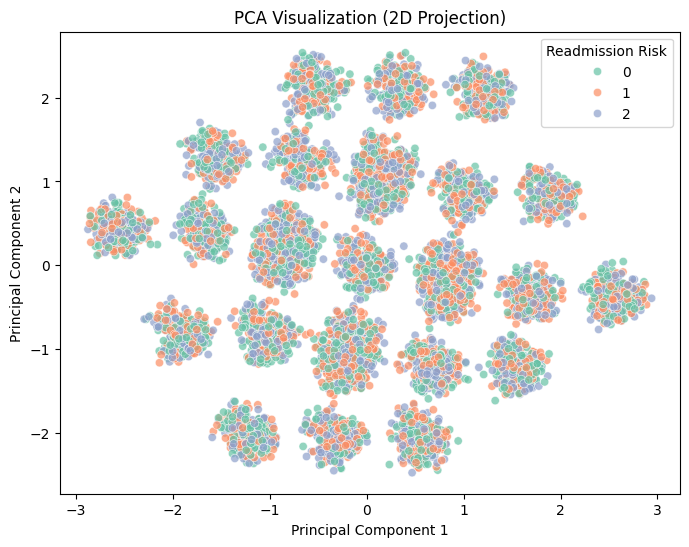

In [581]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_train_scaled)

pca_df = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
pca_df['readmission_risk'] = y_train.values

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='readmission_risk',
    palette='Set2',
    alpha=0.7
)

plt.title("PCA Visualization (2D Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Readmission Risk")
plt.show()

<a id="algorithm-section"></a>
# Machine learning algorithms and optimization

**Cross validation**

In [582]:
skf = StratifiedKFold(n_splits= 5, shuffle= True, random_state=42)

**Dictionary of parameters**

In [583]:
# Logistic Regression
lr_params = {
    'C' : [0.01, 0.1, 1, 10],
    'solver' : ['lbfgs', 'saga'],
    'max_iter' : [1000],
    'penalty': ['l1', 'l2']
}

# KNN
knn_params = {
    'n_neighbors': [3, 5, 7, 11, 15, 30],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Decision Tree
dt_params = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Random Forest
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Hyperparameter Tuning on Original Features

**1. Logistic Regression**

In [584]:
metric = 'f1_macro'

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid=lr_params,
    cv=skf, 
    scoring=metric,
    n_jobs=-1
)

lr_grid.fit(X_train_scaled, y_train)
print("LOGISTIC REGRESSION, ORIGINAL FEATURES")
print(f"Best parameters: {lr_grid.best_params_}")
print(f"Best cross-validation {metric}: {lr_grid.best_score_:.4f}")

LOGISTIC REGRESSION, ORIGINAL FEATURES
Best parameters: {'C': 1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}
Best cross-validation f1_macro: 0.3312


**2. KNN**

In [585]:
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=knn_params,
    cv=skf,
    scoring=metric,
    n_jobs=-1
)

knn_grid.fit(X_train_scaled, y_train)
print("KNN, ORIGINAL FEATURES")
print(f"Best parameters: {knn_grid.best_params_}")
print(f"Best cross-validation {metric}: {knn_grid.best_score_:.4f}")

KNN, ORIGINAL FEATURES
Best parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Best cross-validation f1_macro: 0.3287


**3. Decision Tree**

In [586]:
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=dt_params,
    cv=skf,
    scoring=metric,   
    n_jobs=-1
)

dt_grid.fit(X_train_scaled, y_train)

print("DECISION TREE, ORIGINAL FEATURES")
print(f"Best parameters: {dt_grid.best_params_}")
print(f"Best cross-validation {metric}: {dt_grid.best_score_:.4f}")

DECISION TREE, ORIGINAL FEATURES
Best parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best cross-validation f1_macro: 0.3329


**4. Random Forest**

In [587]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=skf,
    scoring=metric,  
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)

print("RANDOM FOREST, ORIGINAL FEATURES")
print(f"Best parameters: {rf_grid.best_params_}")
print(f"Best cross-validation {metric}: {rf_grid.best_score_:.4f}")

RANDOM FOREST, ORIGINAL FEATURES
Best parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best cross-validation f1_macro: 0.3369


# Hyperparameter Tuning on PCA features

In [588]:
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("--- Dimensionality Reduction using PCA ---")
print(f"Original number of features: {X_train_scaled.shape[1]}")
print(f"Number of features after PCA to preserve 95% variance: {X_train_pca.shape[1]}")

--- Dimensionality Reduction using PCA ---
Original number of features: 25
Number of features after PCA to preserve 95% variance: 22


**1. Logistic Regression**

In [589]:
metric = 'f1_macro'

lr_grid_pca = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid=lr_params,
    cv=skf, 
    scoring=metric,
    n_jobs=-1
)

lr_grid_pca.fit(X_train_pca, y_train)
print("LOGISTIC REGRESSION, PCA FEATURES")
print(f"Best parameters: {lr_grid_pca.best_params_}")
print(f"Best cross-validation {metric}: {lr_grid_pca.best_score_:.4f}")

LOGISTIC REGRESSION, PCA FEATURES
Best parameters: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'saga'}
Best cross-validation f1_macro: 0.3322


**2. KNN**

In [590]:
knn_grid_pca = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=knn_params,
    cv=skf,
    scoring=metric,
    n_jobs=-1
)

knn_grid_pca.fit(X_train_pca, y_train)
print("KNN, PCA FEATURES")
print(f"Best parameters: {knn_grid_pca.best_params_}")
print(f"Best cross-validation {metric}: {knn_grid_pca.best_score_:.4f}")

KNN, PCA FEATURES
Best parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best cross-validation f1_macro: 0.3362


# Hyperparameter Tuning on LDA features

In [591]:
lda = LDA()

X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

print(f"Shape LDA - Train: {X_train_lda.shape}, Test: {X_test_lda.shape}")
print(f"Explained variance by LDA components: {lda.explained_variance_ratio_}")

Shape LDA - Train: (8999, 2), Test: (1000, 2)
Explained variance by LDA components: [0.66073208 0.33926792]


**1. Logistic Regression**

In [592]:
metric = 'f1_macro'

lr_grid_lda = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid=lr_params,
    cv=skf, 
    scoring=metric,
    n_jobs=-1
)

lr_grid_lda.fit(X_train_lda, y_train)
print("LOGISTIC REGRESSION, LDA FEATURES")
print(f"Best parameters: {lr_grid_lda.best_params_}")
print(f"Best cross-validation {metric}: {lr_grid_lda.best_score_:.4f}")

LOGISTIC REGRESSION, LDA FEATURES
Best parameters: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}
Best cross-validation f1_macro: 0.3583


**2. KNN**

In [593]:
knn_grid_lda = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=knn_params,
    cv=skf,
    scoring=metric,
    n_jobs=-1
)

knn_grid_lda.fit(X_train_lda, y_train)
print("KNN, LDA FEATURES")
print(f"Best parameters: {knn_grid_lda.best_params_}")
print(f"Best cross-validation {metric}: {knn_grid_lda.best_score_:.4f}")

KNN, LDA FEATURES
Best parameters: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}
Best cross-validation f1_macro: 0.3393


<a id="evaluation-section"></a>
# Model Evaluation and Comparison

**Logistic Regression (Baseline Model) – Evaluation**

add explanation

In [594]:
best_lr = lr_grid_lda.best_estimator_

y_pred_lr = best_lr.predict(X_test_lda)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Test Accuracy (Logistic Regression - LDA): {accuracy_lr:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))


Test Accuracy (Logistic Regression - LDA): 0.3410

Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.33      0.33       333
           1       0.34      0.38      0.36       333
           2       0.34      0.31      0.33       334

    accuracy                           0.34      1000
   macro avg       0.34      0.34      0.34      1000
weighted avg       0.34      0.34      0.34      1000



Confusion Matrix

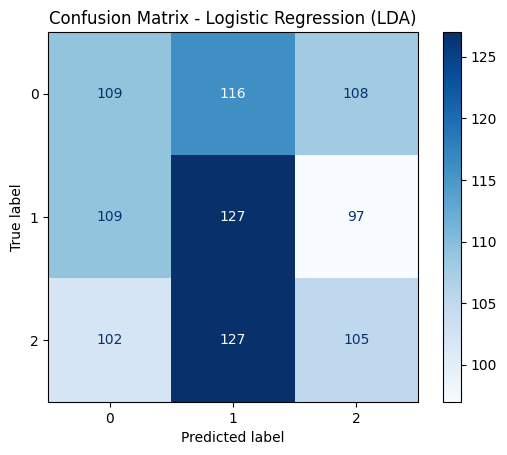

In [595]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression (LDA)")
plt.show()

**Final Evaluation on Test Set**

In [596]:
results = []

# ---- 1. Logistic Regression (LDA) ----
lr_model = lr_grid_lda.best_estimator_
y_pred_lr = lr_model.predict(X_test_lda)

results.append({
    "Model": "Logistic Regression (LDA)",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision_macro": precision_score(y_test, y_pred_lr, average='macro'),
    "Recall_macro": recall_score(y_test, y_pred_lr, average='macro'),
    "F1_macro": f1_score(y_test, y_pred_lr, average='macro'),
    "F1_weighted": f1_score(y_test, y_pred_lr, average='weighted')
})


# ---- 2. KNN (PCA) ----
knn_model = knn_grid_pca.best_estimator_
y_pred_knn = knn_model.predict(X_test_pca)

results.append({
    "Model": "KNN (PCA)",
    "Accuracy": accuracy_score(y_test, y_pred_knn),
    "Precision_macro": precision_score(y_test, y_pred_knn, average='macro'),
    "Recall_macro": recall_score(y_test, y_pred_knn, average='macro'),
    "F1_macro": f1_score(y_test, y_pred_knn, average='macro'),
    "F1_weighted": f1_score(y_test, y_pred_knn, average='weighted')
})


# ---- 3. Decision Tree (Original) ----
dt_model = dt_grid.best_estimator_
y_pred_dt = dt_model.predict(X_test_scaled)

results.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision_macro": precision_score(y_test, y_pred_dt, average='macro'),
    "Recall_macro": recall_score(y_test, y_pred_dt, average='macro'),
    "F1_macro": f1_score(y_test, y_pred_dt, average='macro'),
    "F1_weighted": f1_score(y_test, y_pred_dt, average='weighted')
})


# ---- 4. Random Forest (Original) ----
rf_model = rf_grid.best_estimator_
y_pred_rf = rf_model.predict(X_test_scaled)

results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision_macro": precision_score(y_test, y_pred_rf, average='macro'),
    "Recall_macro": recall_score(y_test, y_pred_rf, average='macro'),
    "F1_macro": f1_score(y_test, y_pred_rf, average='macro'),
    "F1_weighted": f1_score(y_test, y_pred_rf, average='weighted')
})


# Convert to DataFrame
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted
0,Logistic Regression (LDA),0.34,0.34,0.34,0.34,0.34
1,KNN (PCA),0.32,0.32,0.32,0.32,0.32
2,Decision Tree,0.32,0.32,0.32,0.32,0.32
3,Random Forest,0.32,0.32,0.32,0.32,0.32


**CONFUSION MATRICES**

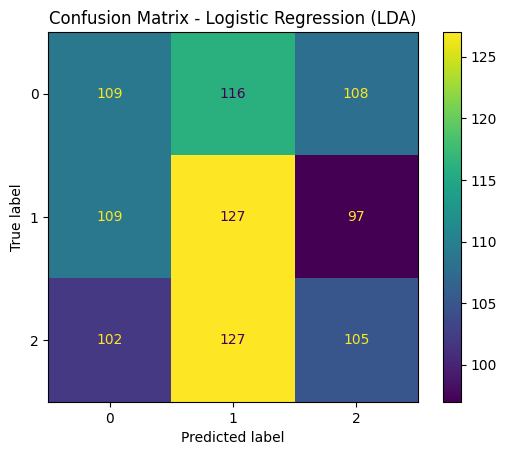

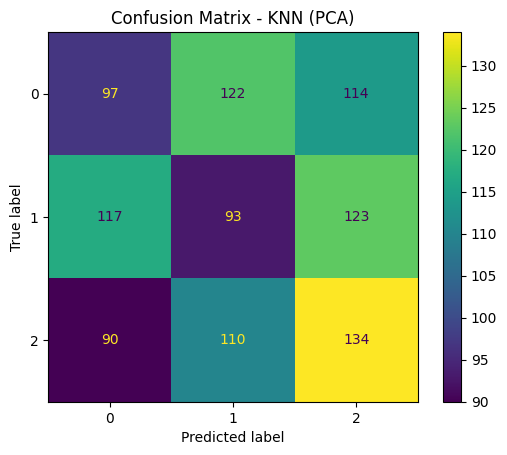

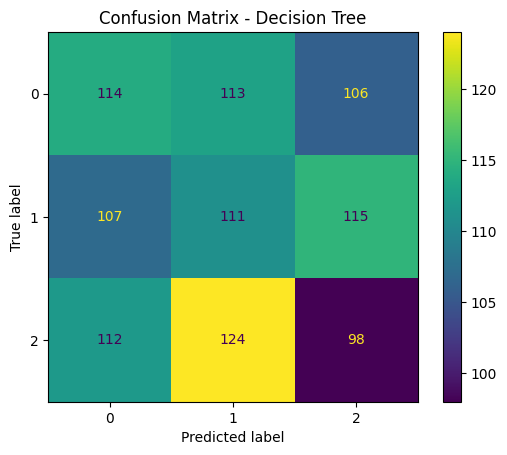

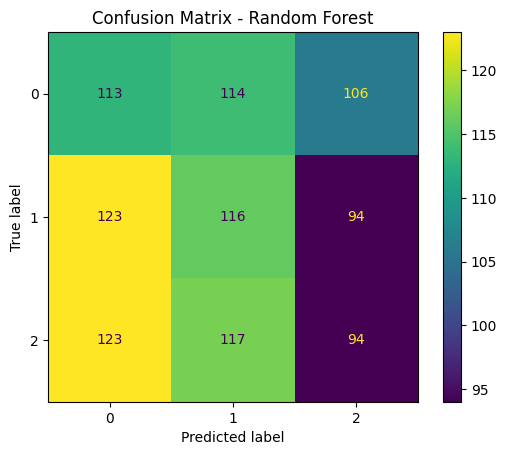

In [597]:
models_predictions = {
    "Logistic Regression (LDA)": y_pred_lr,
    "KNN (PCA)": y_pred_knn,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf
}

for name, y_pred in models_predictions.items():
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()